# **Learning Rate Scheduling and Adam Optimizer**


การเรียนรู้ของ AI เหมือนการเรียนขับรถ ลองนึกภาพว่าคุณกำลังสอนเด็กขับรถ ในช่วงแรกเด็กยังไม่รู้อะไรเลย คุณต้องสอนทีละขั้นตอน หมุนพวงมาลัยไปทางไหน รถจะไปทางนั้น เหยียบคันเร่ง รถจะเร็วขึ้น เหยียบเบรก รถจะช้าลง คำถามสำคัญคือ ควรให้เด็กฝึกขับเร็วแค่ไหน

คำถามสำคัญคือ ควรให้เด็กฝึกขับเร็วแค่ไหน เร็วเกินไป อาจเกิดอุบัติเหตุ ควบคุมไม่ได้ ช้าเกินไป เรียนรู้ช้า อาจไม่มีวันขับเป็น หรือ พอดี เริ่มช้า ๆ แล้วค่อย ๆ เร็วขึ้นเมื่อชำนาญ

ในโลกของ AI และ Deep Learning, Learning Rate คือ ความเร็วในการเรียนรู้ ของ AI ถ้าเร็วเกินไป AI จะ กระโดด ข้ามคำตอบที่ดี ถ้าช้าเกินไป  AI จะใช้เวลานานมากกว่าจะเก่ง การปรับ Learning Rate ให้เหมาะสม = Optimization

## **ตัวอย่าง AI เรียนรู้การแยกรูป หมา กับ แมว**


### Without good optimization

model.compile(optimizer='sgd')  # ใช้ default,

 ไม่ได้ปรับอะไร

history = model.fit(X, y, epochs=100)

ผลลัพธ์ -> accuracy = 65%
เวลาที่ใช้ -> 2 ชั่วโมง

In [4]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import numpy as np
# สมมติว่าใช้ pandas ในการโหลดข้อมูล
import pandas as pd

# =============================================================
#  ส่วนที่ 1: โหลดและเตรียมข้อมูล (ต้องทำก่อน)
# =============================================================

# !!! สำคัญ: คุณต้องแทนที่ส่วนนี้ด้วยโค้ดโหลดข้อมูลของคุณเอง !!!

# --- ตัวอย่างที่ 1: ถ้าข้อมูลมาจากไฟล์ CSV ---
# df = pd.read_csv('your_data.csv')
# X = df[['feature1', 'feature2', 'feature3']].values  # เลือกเฉพาะคอลัมน์ที่เป็น feature
# y = df['target_column'].values                       # เลือกคอลัมน์ที่เป็นคำตอบ

# --- ตัวอย่างที่ 2: ถ้าข้อมูลเป็น numpy array ที่สร้างขึ้นมา ---
# สร้างข้อมูลตัวอย่างขึ้นมาเพื่อให้โค้ดรันได้
print("Creating sample data for X and y...")
X = np.random.rand(1000, 20) # ข้อมูลตัวอย่าง: 1000 แถว, 20 features
y = np.random.randint(0, 2, 1000) # คำตอบตัวอย่าง: 0 หรือ 1

print(f"Data X is ready with shape: {X.shape}")


# =============================================================
#  ส่วนที่ 2: สร้างโมเดล (ตอนนี้ Python รู้จัก X แล้ว)
# =============================================================

print("Building the model...")
model = keras.Sequential([
    # ตอนนี้ X.shape[1] จะทำงานได้ถูกต้อง เพราะ Python รู้จัก X แล้ว
    layers.Dense(units=64, activation='relu', input_shape=[X.shape[1]]),
    layers.Dense(units=32, activation='relu'),
    layers.Dense(units=1, activation='sigmoid')
])

model.summary()


# =============================================================
#  ส่วนที่ 3: คอมไพล์และฝึกสอนโมเดล
# =============================================================

print("\nCompiling the model...")
model.compile(optimizer='adam',
              loss='binary_crossentropy',
              metrics=['accuracy'])

print("Starting training...")
history = model.fit(X, y, epochs=100)
print("Training finished.")


Creating sample data for X and y...
Data X is ready with shape: (1000, 20)
Building the model...


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │         1,344 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,457 (13.50 KB)

 Trainable params: 3,457 (13.50 KB)

 Non-trainable params: 0 (0.00 B)


Compiling the model...
Starting training...
Epoch 1/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.5107 - loss: 0.6993
Epoch 2/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5303 - loss: 0.6901
Epoch 3/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5058 - loss: 0.6897
Epoch 4/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.5406 - loss: 0.6879 
Epoch 5/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.5504 - loss: 0.6842
Epoch 6/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.5668 - loss: 0.6843 
Epoch 7/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.5550 - loss: 0.6859
Epoch 8/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.5545 - loss: 0.6806 
Epoch 9/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.5868 - loss: 0.6772
Epoch 10/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.5994 - loss: 0.6757
Epoch 11/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.5807 - loss: 0.6728
Epoch 12/100
32

In [6]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import numpy as np

# --- Import ส่วนที่จำเป็นเพิ่มเข้ามา ---
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.optimizers.schedules import CosineDecay


# 1. สร้างข้อมูล (เหมือนเดิม)
X = np.random.rand(1000, 20)
y = np.random.randint(0, 2, 1000)


# 2. สร้างโมเดล (เหมือนเดิม)
model = keras.Sequential([
    keras.Input(shape=[X.shape[1]]),
    layers.Dense(64, activation='relu'),
    layers.Dense(32, activation='relu'),
    layers.Dense(1, activation='sigmoid')
])


# --- ส่วนที่แก้ไขใหม่ ---

# 3. กำหนดค่าและสร้าง Learning Rate Schedule
epochs = 100
batch_size = 32 # กำหนด batch_size เพื่อคำนวณ decay_steps
# คำนวณจำนวน step ทั้งหมดในการเทรน
total_steps = int(len(X) / batch_size) * epochs

# สร้าง CosineDecay schedule
# มันจะลด learning rate จาก 0.001 ไปจนถึง 0 ใน total_steps
lr_schedule = CosineDecay(
    initial_learning_rate=0.001,
    decay_steps=total_steps
)

# 4. สร้าง Optimizer โดยใช้ Schedule ที่เพิ่งสร้าง
# ส่ง lr_schedule เข้าไปที่พารามิเตอร์ learning_rate
optimizer = Adam(learning_rate=lr_schedule)

# 5. Compile โมเดล
model.compile(optimizer=optimizer,
              loss='binary_crossentropy',
              metrics=['accuracy'])

# 6. ฝึกสอนโมเดล
# ไม่ต้องใส่ lr_scheduler ใน callbacks แล้ว เพราะมันเป็นส่วนหนึ่งของ optimizer ไปแล้ว
print("Starting training with Adam and CosineDecay...")
history = model.fit(X, y, epochs=epochs, batch_size=batch_size, verbose=1) # verbose=1 เพื่อให้แสดงผลการเทรน
print("Training finished.")

# ผลลัพธ์ที่คาดหวัง: accuracy ควรจะสูงขึ้น และอาจจะลู่เข้า (converge) ได้เร็วกว่าเดิม
final_accuracy = history.history['accuracy'][-1]
print(f"\nFinal training accuracy: {final_accuracy*100:.2f}%")

Starting training with Adam and CosineDecay...
Epoch 1/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.4706 - loss: 0.7193
Epoch 2/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.5063 - loss: 0.6930
Epoch 3/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.5173 - loss: 0.6912 
Epoch 4/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.5379 - loss: 0.6896
Epoch 5/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5439 - loss: 0.6861
Epoch 6/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.5288 - loss: 0.6865 
Epoch 7/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.5683 - loss: 0.6855
Epoch 8/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.5873 - loss: 0.6767 
Epoch 9/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.5703 - loss: 0.6805
Epoch 10/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.5892 - loss: 0.6787
Epoch 11/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.5820 - loss: 0.6742 
Epoch 12/100

**# Function จำลองการหาค่าต่ำสุดของ y = x^2 (จำลอง Gradient Descent)**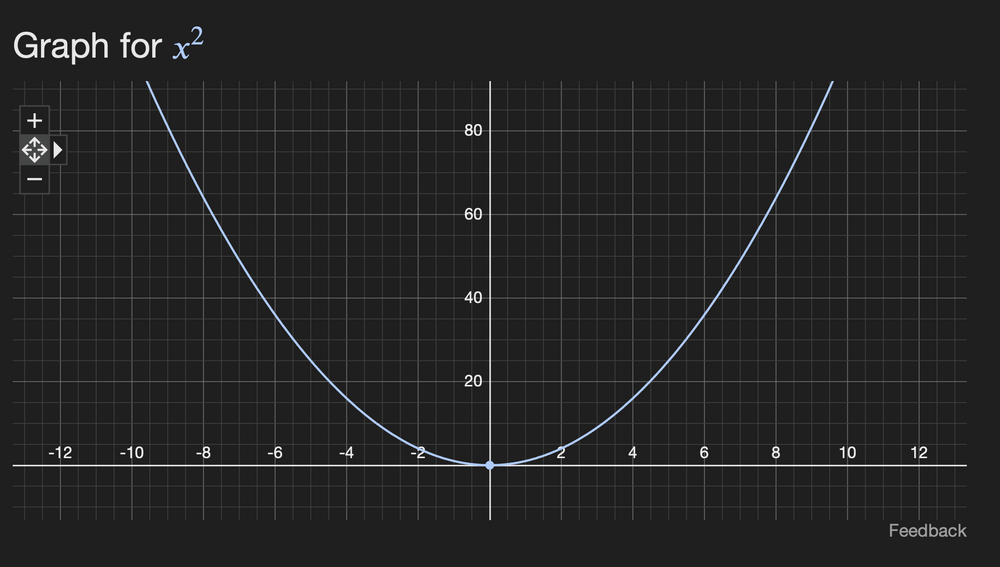

In [7]:
def simple_gradient_descent():
    # เริ่มที่ x=10 (ห่างจากคำตอบที่ถูกคือ x=0)
    x = 10
    learning_rate = 0.1  # ขนาดของการก้าว

    print("เริ่มการเดินทางลงจากภูเขา...")

    for step in range(20):
        # 1. คำนวณความชัน (gradient) ที่จุดปัจจุบัน
        # สำหรับ y = x^2, gradient = 2x
        gradient = 2 * x

        # 2. ก้าวไปในทิศตรงข้ามกับความชัน
        # ถ้าความชันเป็นบวก = ลาดขึ้น -> เราเดินลง
        x = x - learning_rate * gradient

        # 3. คำนวณค่า loss (ความสูงจากพื้น)
        loss = x ** 2

        print(f"Step {step+1} ตำแหน่ง x={x:.3f}, ความสูง={loss:.3f}")

        # ถ้าใกล้พื้นมากแล้ว (loss < 0.001) ให้หยุด
        if loss < 0.001:
            print("ถึงจุดต่ำสุดแล้ว!")
            break

    return x

final_position = simple_gradient_descent()

เริ่มการเดินทางลงจากภูเขา...
Step 1 ตำแหน่ง x=8.000, ความสูง=64.000
Step 2 ตำแหน่ง x=6.400, ความสูง=40.960
Step 3 ตำแหน่ง x=5.120, ความสูง=26.214
Step 4 ตำแหน่ง x=4.096, ความสูง=16.777
Step 5 ตำแหน่ง x=3.277, ความสูง=10.737
Step 6 ตำแหน่ง x=2.621, ความสูง=6.872
Step 7 ตำแหน่ง x=2.097, ความสูง=4.398
Step 8 ตำแหน่ง x=1.678, ความสูง=2.815
Step 9 ตำแหน่ง x=1.342, ความสูง=1.801
Step 10 ตำแหน่ง x=1.074, ความสูง=1.153
Step 11 ตำแหน่ง x=0.859, ความสูง=0.738
Step 12 ตำแหน่ง x=0.687, ความสูง=0.472
Step 13 ตำแหน่ง x=0.550, ความสูง=0.302
Step 14 ตำแหน่ง x=0.440, ความสูง=0.193
Step 15 ตำแหน่ง x=0.352, ความสูง=0.124
Step 16 ตำแหน่ง x=0.281, ความสูง=0.079
Step 17 ตำแหน่ง x=0.225, ความสูง=0.051
Step 18 ตำแหน่ง x=0.180, ความสูง=0.032
Step 19 ตำแหน่ง x=0.144, ความสูง=0.021
Step 20 ตำแหน่ง x=0.115, ความสูง=0.013


# **สิ่งที่เกิดขึ้นในแต่ละ Step**
ตำแหน่งเริ่มต้น x = 10
Loss ณ จุดนี้ 100

Step 1 คำนวณ Gradient
Gradient = 2 × 10 = 20
หมายความว่า ถ้าเดินไปทางขวา loss จะเพิ่มขึ้น

Step 2 Update ตำแหน่ง
ตำแหน่งใหม่ = 10 - 0.1 × 20
ตำแหน่งใหม่ = 8.0 (ดินไปทางซ้าย)

Step 3 ตรวจสอบผล
Loss เดิม 100
Loss ใหม่ 64.0
ดีขึ้น 36.00

# **Gradient (ความชัน) = ทิศทางและความชันของพื้นผิว**

บวก (+) = ลาดขึ้น
ลบ (-) = ลาดลง
ศูนย์ (0) = พื้นราบ

Learning Rate = ขนาดของก้าวที่เดิน
ยิ่งมาก = ก้าวยาว
ยิ่งน้อย = ก้าวสั้น

Loss/Cost Function = ความผิดพลาดที่เราพยายามลด
ยิ่งต่ำ = AI ยิ่งเก่ง
เป้าหมาย = หาจุดที่ต่ำที่สุด

# **ปัญหาของ Fixed Learning Rate**

### **1. Learning Rate สูงเกินไป เหมือนพยายามลงบันไดโดยกระโดดครั้งละ 10 ขั้น อาจทำให้เกิดการกระโดดข้ามคำตอบ**

Learning Rate สูงเกินไป (เช่น 1.5)

Step 0: x =  -8.000, Loss =  64.000
Step 1: x =  16.000, Loss = 256.000
Step 2: x = -32.000, Loss = 1024.000
Step 3: x =  64.000, Loss = 4096.000
Step 4: x = -128.000, Loss = 16384.000
❌ DIVERGED! Loss กำลังเพิ่มขึ้นแทนที่จะลดลง!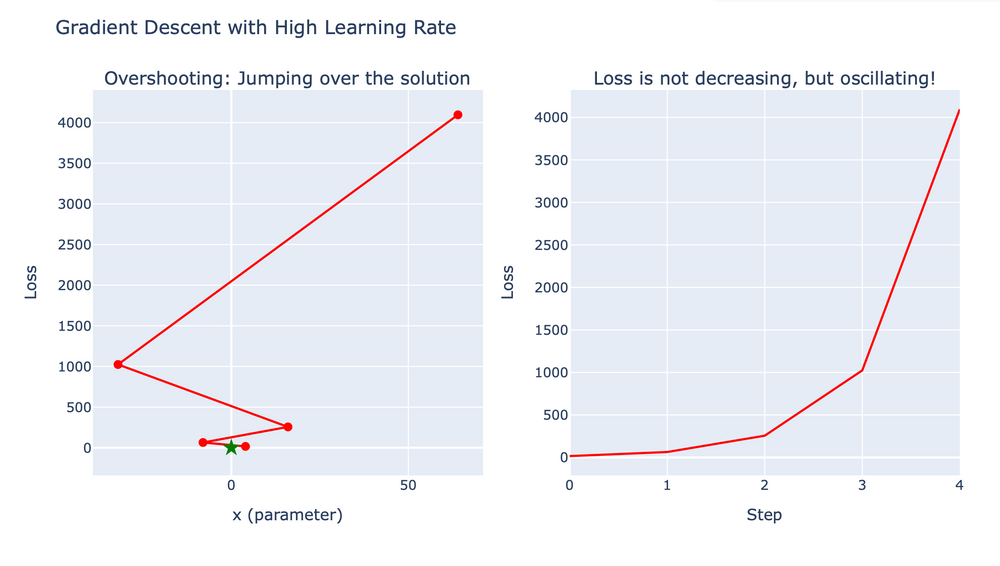

จากภาพ Learning Rate สูงเกินไป ทำให้ AI กระโดดข้ามจุดที่ดีที่สุดไปมา โดย Loss กลับแกว่งหรือเพิ่มขึ้น จึงไม่สามารถหาคำตอบที่ดีได้

### **2. Learning Rate ต่ำเกินไป เหมือนพยายามลงบันไดทีละ 1 มิลลิเมตรทำข้อความเป็นตัวหนาทำข้อความเป็นตัวหนา**

Learning Rate ต่ำเกินไป (เช่น 0.001)

Step     0: x =   9.980, Loss =  99.600

Step  1000: x =   1.348, Loss =   1.817

Step  2000: x =   0.182, Loss =   0.033

ต้องใช้ 2300 steps จึงจะถึงเป้าหมาย

ถ้า 1 step = 1 วินาที -> ใช้เวลา 38.3 นาที

ถ้าใช้ LR = 0.1 -> อาจใช้แค่ ~ 20 steps (~20 วินาที)

# 3. การติดอยู่ใน Local Minima คือ การติดอยู่ในหลุมเล็ก ๆ แทนที่จะไปถึงหลุมที่ลึกที่สุด เหมือนคิดว่าร้านข้างบ้านถูกที่สุดแล้ว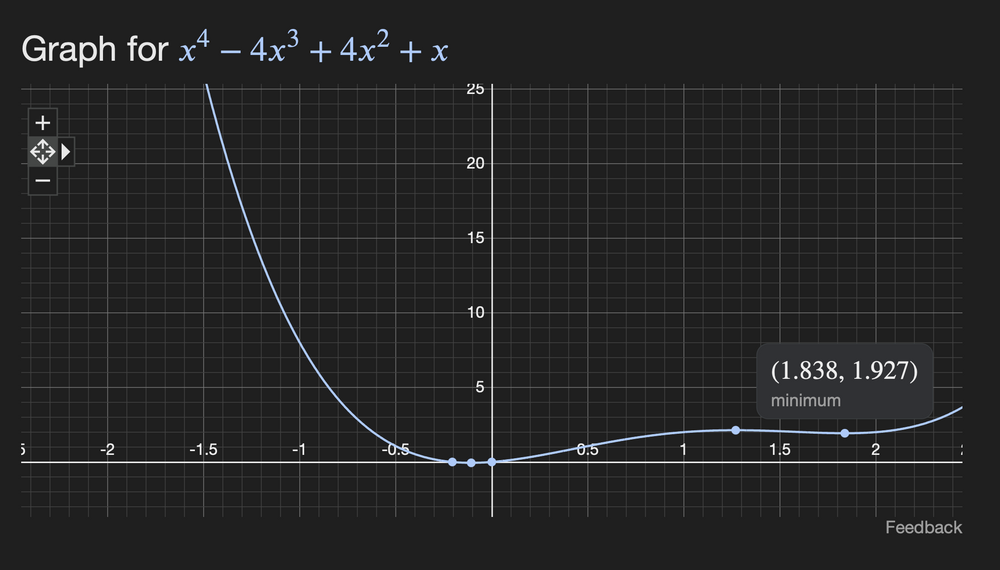

In [6]:
def problem_local_minima():
    import numpy as np

    # สร้าง loss function ที่มีหลายหลุม
    def complex_loss(x):
        return x**4 - 4*x**3 + 4*x**2 + x

    def complex_gradient(x):
        # Gradient ของ complex loss
        return 4*x**3 - 12*x**2 + 8*x + 1

    # ลองเริ่มจากหลายจุด
    starting_points = [-1, 0, 1, 3]
    results = []

    for start_x in starting_points:
        x = start_x
        lr = 0.01

        # Train 100 steps
        for _ in range(100):
            x = x - lr * complex_gradient(x)

        final_loss = complex_loss(x)
        results.append((start_x, x, final_loss))

        print(f"Start: x={start_x:4.1f} → End: x={x:6.3f}, Loss={final_loss:6.3f}")

    # หา global minimum
    best_result = min(results, key=lambda r: r[2])
    worst_result = max(results, key=lambda r: r[2])

    print(f"Best  Start={best_result[0]}, Final Loss={best_result[2]:.3f}")
    print(f"Worst Start={worst_result[0]}, Final Loss={worst_result[2]:.3f}")
    print(f"Difference {worst_result[2] - best_result[2]:.3f}")

problem_local_minima()

Start: x=-1.0 → End: x=-0.107, Loss=-0.056
Start: x= 0.0 → End: x=-0.107, Loss=-0.056
Start: x= 1.0 → End: x=-0.107, Loss=-0.056
Start: x= 3.0 → End: x= 1.841, Loss= 1.927
Best  Start=0, Final Loss=-0.056
Worst Start=3, Final Loss=1.927
Difference 1.983


# 4. Saddle Points คืออาการที่ Loss ไม่ลดต่อ เหมือนอยู่บนเนินราบ ไม่รู้จะไปทางไหน

# **สรุปปัญหาของการ Fixed Learning Rate**
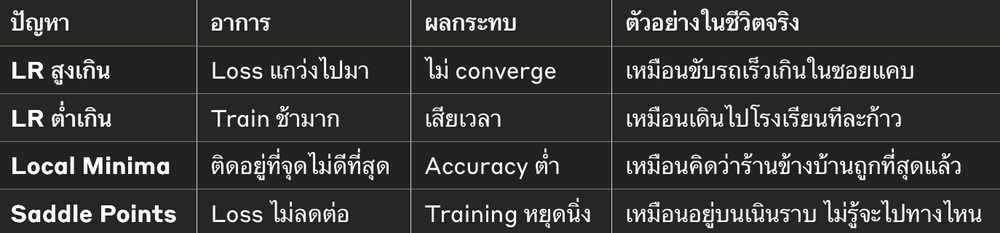

# **Learning Rate Scheduling**

เพื่อแก้ปัญหา Fixed Learning Rate เราจะใช้การปรับความเร็วอย่างชาญฉลาด เหมือนกับการขับรถไปที่ไม่เคยไป เช่น ช่วงแรก ขับเร็วได้บนทางหลวง ช่วงกลาง ชะลอลงเมื่อเข้าเมือง และ ช่วงท้าย ขับช้า ๆ หาที่จอด ซึ่งการปรับความเร็วมีหลายวิธี ดังภาพเปรียบเทียบ LR scheduling methods ด้านล่าง
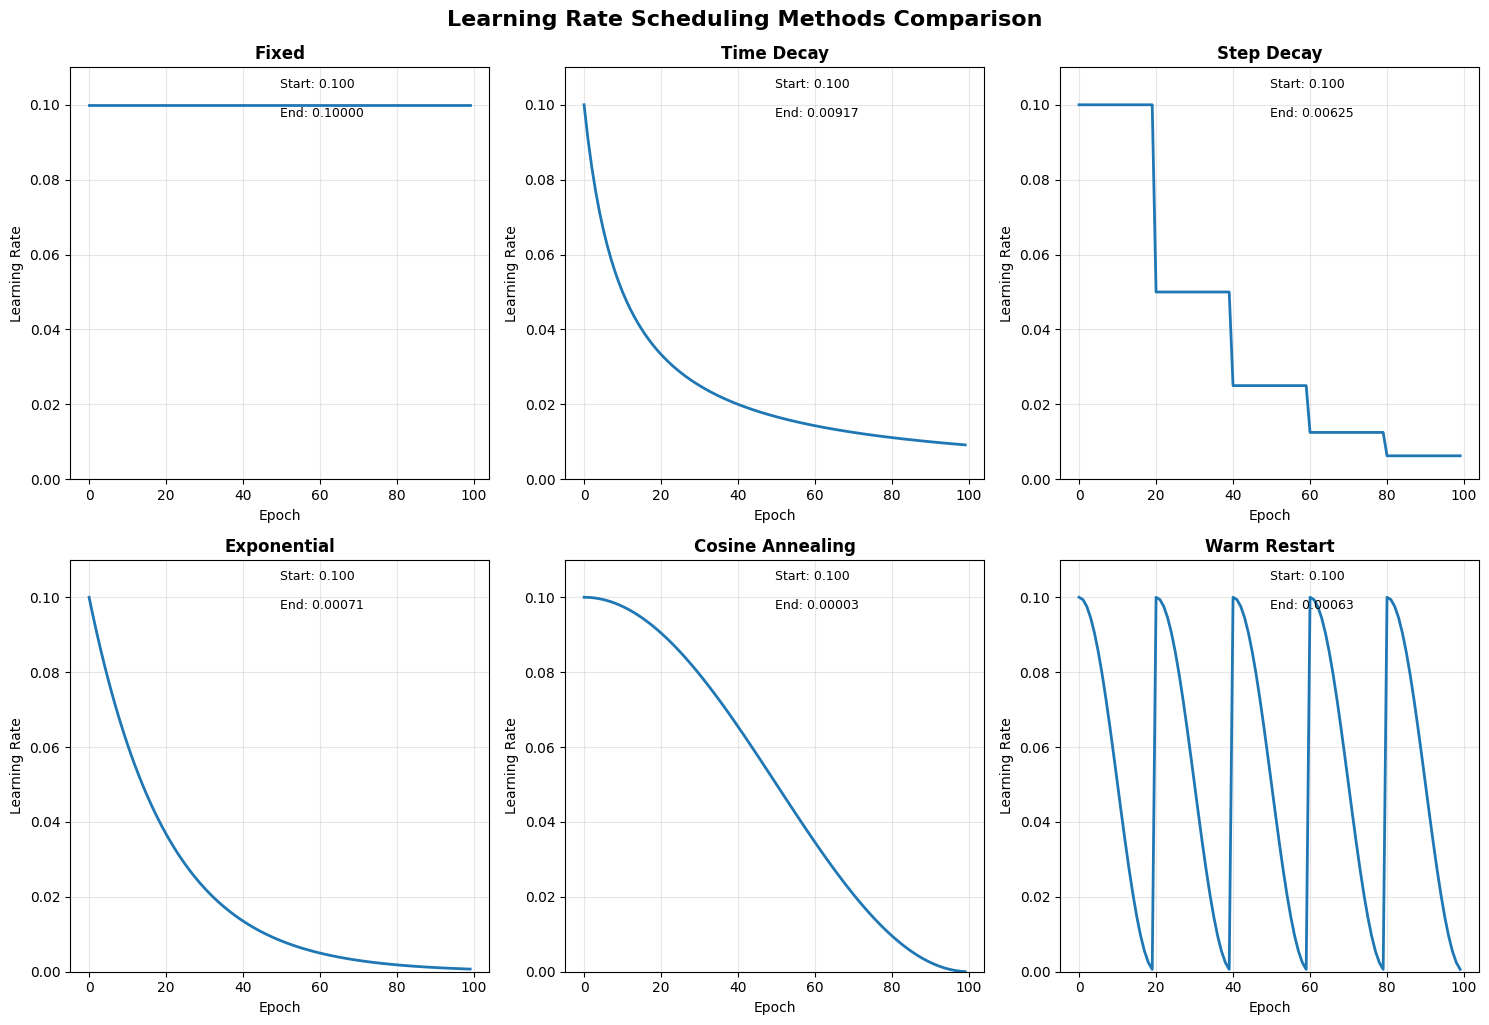

# 1. Time-based decay
ลด Learning Rate ลงอย่างนุ่มนวลตามเวลา เมื่อเข้าใกล้จุดต่ำสุดของ Loss Function แล้ว การก้าวที่เล็กลงอย่างนุ่มนวลจะช่วยให้ Model  สามารถปรับได้ละเอียดเพื่อหาจุดที่ดีที่สุดจริง ๆ ได้

การลด Learning Rate ในช่วงท้ายของการ Train จะช่วยลดการแกว่งไปมาของ Loss และ Parameter ทำให้การ Convergence มีประสิทธิภาพมากขึ้น

lr = lr0 / (1 + decay * epoch)



 lr0 คือ Initial Learning Rate

decay ยิ่งมาก ยิ่งลดเร็ว

In [9]:
from tensorflow.keras.callbacks import LearningRateScheduler

def time_decay_schedule(epoch, lr):
	initial_lr = 0.01
	decay = 0.01

	new_lr = initial_lr / (1 + decay * epoch)
	return new_lr

lr_scheduler = LearningRateScheduler(time_decay_schedule, verbose=0)

model.compile(optimizer='adam', loss='categorical_crossentropy')
model.fit(X_train, y_train, epochs=100, callbacks=[lr_scheduler])

Epoch 1/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step - accuracy: 0.9270 - loss: 0.1747 - learning_rate: 0.0100
Epoch 2/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9542 - loss: 0.1333 - learning_rate: 0.0099
Epoch 3/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9652 - loss: 0.1087 - learning_rate: 0.0098
Epoch 4/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9673 - loss: 0.0932 - learning_rate: 0.0097
Epoch 5/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9356 - loss: 0.1762 - learning_rate: 0.0096
Epoch 6/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9635 - loss: 0.1113 - learning_rate: 0.0095
Epoch 7/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9417 - loss: 0.1495 - learning_rate: 0.0094
Epoch 8/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9420 - loss: 0.1383 - learning_rate: 0.0093
Epoch 9/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9318 - loss: 0.1750 - learning_rate: 0.0093
Epoch 10/100
32/32

In [3]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.callbacks import LearningRateScheduler
import numpy as np # เพิ่มเข้ามาสำหรับสร้างข้อมูลตัวอย่าง

# --- สร้างข้อมูลตัวอย่าง (หากคุณยังไม่มี) ---
# สมมติว่ามี 10 features และ 3 classes (คำตอบ)
X_train = np.random.rand(1000, 10)
y_train = tf.keras.utils.to_categorical(np.random.randint(3, size=1000), num_classes=3)


# =================================================================
# === ส่วนที่ขาดไป: การสร้างโมเดล (ต้องเพิ่มส่วนนี้เข้าไป) ===
# =================================================================
model = Sequential([
    # Input Layer: ต้องระบุ input_shape ให้ตรงกับจำนวน features ของข้อมูล
    Dense(128, activation='relu', input_shape=(X_train.shape[1],)),

    # Hidden Layer
    Dense(64, activation='relu'),

    # Output Layer: จำนวน unit ต้องเท่ากับจำนวน class ของคำตอบ
    # และใช้ 'softmax' สำหรับ multi-class classification
    Dense(y_train.shape[1], activation='softmax')
])

# แสดงสรุปสถาปัตยกรรมของโมเดลที่เราสร้าง
model.summary()


# =================================================================
# === โค้ดเดิมของคุณ (ซึ่งถูกต้องอยู่แล้ว) ===
# =================================================================
from tensorflow.keras.callbacks import LearningRateScheduler

def time_decay_schedule(epoch, lr):
    initial_lr = 0.01
    decay = 0.01

    new_lr = initial_lr / (1 + decay * epoch)
    return new_lr

lr_scheduler = LearningRateScheduler(time_decay_schedule, verbose=0)

# ตอนนี้ Python รู้จัก 'model' แล้ว บรรทัดนี้จะทำงานได้
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
model.fit(X_train, y_train, epochs=100, callbacks=[lr_scheduler])


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │         1,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 9,859 (38.51 KB)

 Trainable params: 9,859 (38.51 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 3s 26ms/step - accuracy: 0.3145 - loss: 1.1246 - learning_rate: 0.0100
Epoch 2/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.3178 - loss: 1.1000 - learning_rate: 0.0099
Epoch 3/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.3508 - loss: 1.0969 - learning_rate: 0.0098
Epoch 4/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.3480 - loss: 1.0966 - learning_rate: 0.0097
Epoch 5/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.3317 - loss: 1.0985 - learning_rate: 0.0096
Epoch 6/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.3424 - loss: 1.0966 - learning_rate: 0.0095
Epoch 7/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.3530 - loss: 1.0937 - learning_rate: 0.0094
Epoch 8/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.3704 - loss: 1.0909 - learning_rate: 0.0093
Epoch 9/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.3079 - loss: 1.1036 - learning_rate: 0.0093
Epoch 10/100
32/32

# 2. Step Decay
ลด Learning Rate เป็นขั้นบันได เพื่อให้เวลา Model ปรับตัวในแต่ละช่วง

In [10]:
def implement_step_decay():
    import math

    def step_decay_schedule(epoch):
        initial_lr = 0.1

        # ลด LR ลง 50% ทุกๆ 20 epochs เหมือนลงบันไดทีละชั้น
        drop = 0.5
        epochs_drop = 20  # ลดทุกกี่ epochs

        # คำนวณว่าอยู่ขั้นที่เท่าไหร่
        # math.floor(3.7) จะได้ 3
        step_num = math.floor(epoch / epochs_drop)

        # คำนวณ LR ใหม่
        lr = initial_lr * math.pow(drop, step_num)

        return lr

    # จำลองการ train 100 epochs
    for epoch in range(0, 101, 10):
        lr = step_decay_schedule(epoch)
        step = epoch // 20
        print(f"Epoch {epoch:3} (Step {step}): LR = {lr:.6f}")

    print("\nจุดเปลี่ยนสำคัญ")
    print("Epoch  0-19 LR = 0.100000 (เรียนรู้เร็ว)")
    print("Epoch 20-39 LR = 0.050000 (เริ่มชะลอ)")
    print("Epoch 40-59 LR = 0.025000 (fine-tuning)")
    print("Epoch 60-79 LR = 0.012500 (ปรับละเอียด)")
    print("Epoch 80-99 LR = 0.006250 (จบอย่างนุ่มนวล)")

implement_step_decay()

Epoch   0 (Step 0): LR = 0.100000
Epoch  10 (Step 0): LR = 0.100000
Epoch  20 (Step 1): LR = 0.050000
Epoch  30 (Step 1): LR = 0.050000
Epoch  40 (Step 2): LR = 0.025000
Epoch  50 (Step 2): LR = 0.025000
Epoch  60 (Step 3): LR = 0.012500
Epoch  70 (Step 3): LR = 0.012500
Epoch  80 (Step 4): LR = 0.006250
Epoch  90 (Step 4): LR = 0.006250
Epoch 100 (Step 5): LR = 0.003125

จุดเปลี่ยนสำคัญ
Epoch  0-19 LR = 0.100000 (เรียนรู้เร็ว)
Epoch 20-39 LR = 0.050000 (เริ่มชะลอ)
Epoch 40-59 LR = 0.025000 (fine-tuning)
Epoch 60-79 LR = 0.012500 (ปรับละเอียด)
Epoch 80-99 LR = 0.006250 (จบอย่างนุ่มนวล)


# 3. Exponential Decay
ลด Learning Rate  แบบ exponential โดย Learning Rate ลดลงรวดเร็วกว่า Time-based decay แต่อาจลดเร็วเกินไปจนติด Local minima ก็ได้

lr = lr0 * exp(-k * epoch)

In [12]:
def implement_exponential_decay():
    import math

    def exponential_decay_schedule(epoch):
        initial_lr = 0.01
        decay_rate = 0.1 # ยิ่งมาก ยิ่งลดเร็ว

        new_lr = initial_lr * math.exp(-decay_rate * epoch)

        return new_lr

    for epoch in [0, 10, 20, 50, 100]:
        lr = exponential_decay_schedule(epoch)
        print(f"Epoch {epoch:3}: LR = {lr:.6f}")

    return exponential_decay_schedule

scheduler_exp = implement_exponential_decay()

Epoch   0: LR = 0.010000
Epoch  10: LR = 0.003679
Epoch  20: LR = 0.001353
Epoch  50: LR = 0.000067
Epoch 100: LR = 0.000000


# 4. Cosine Annealing
ลด Learning Rate แบบคลื่น Cosine ที่นุ่มนวล และมักได้ผลดีมากกับ Model ขนาดใหญ่ แต่ต้องรู้จำนวน Epochs ล่วงหน้า

In [13]:
import numpy as np
import plotly.graph_objects as go

def simple_cosine_annealing_schedule(epoch, total_epochs, initial_lr, min_lr=0):
    # สูตร Cosine Annealing
    # (1 + cos(pi * t/T)) / 2 จะให้ค่าจาก 1 ถึง 0
    cosine_value = 0.5 * (1 + np.cos(np.pi * epoch / total_epochs))

    # ปรับ scale ค่า cosine ให้อยู่ในช่วง [min_lr, initial_lr]
    new_lr = min_lr + (initial_lr - min_lr) * cosine_value

    return new_lr

# ตัวอย่างการใช้งานและแสดงผล
total_epochs = 100
initial_lr = 0.01
min_lr = 0.0001 # กำหนด LR ต่ำสุด

epochs_range = list(range(total_epochs)) # Plotly ต้องการ list หรือ array
lrs = [simple_cosine_annealing_schedule(e, total_epochs, initial_lr, min_lr) for e in epochs_range]

# แสดงตัวอย่าง LR ในบาง epoch
for epoch in [0, 25, 50, 75, 99]:
    lr = simple_cosine_annealing_schedule(epoch, total_epochs, initial_lr, min_lr)
    print(f"Epoch {epoch:2} {lr:.6f}")

fig = go.Figure(data=go.Scatter(x=epochs_range, y=lrs, mode='lines'))
fig.update_layout(
    title='Simple Cosine Annealing Learning Rate Schedule',
    xaxis_title='Epoch',
    yaxis_title='Learning Rate',
    hovermode='x unified' # แสดงค่าบนเส้นเมื่อ hover
)
fig.show()

Epoch  0 0.010000
Epoch 25 0.008550
Epoch 50 0.005050
Epoch 75 0.001550
Epoch 99 0.000102


# 5. Warm Restart
รีเซ็ต Learning Rate เป็นรอบ ๆ โดย Warm Restartใช้ Cosine Annealing เป็นกลไกหลักในการปรับลด Learning Rate ภายในแต่ละรอบ รอบถัดไปจะมีความยาวนานขึ้น (ตามค่า cycle_mult) ทำให้ช่วงเวลาที่ Learning Rate ลดลงในแต่ละรอบยาวขึ้นเรื่อย ๆ

In [14]:
import numpy as np
import plotly.graph_objects as go

def simple_warm_restart_schedule(epoch, initial_lr, min_lr, cycle_length, cycle_mult=2):
    # หาว่าตอนนี้อยู่ในรอบที่เท่าไหร่ และ epoch ที่เท่าไหร่ในรอบนั้น
    current_cycle = 0
    epoch_in_cycle = epoch
    current_cycle_length = cycle_length

    while epoch_in_cycle >= current_cycle_length:
        epoch_in_cycle -= current_cycle_length
        current_cycle += 1
        current_cycle_length *= cycle_mult # รอบถัดไปยาวขึ้น

    # คำนวณ LR ในรอบปัจจุบันโดยใช้ Cosine Annealing ภายในรอบนั้น
    progress_in_cycle = epoch_in_cycle / current_cycle_length
    cosine_value = 0.5 * (1 + np.cos(np.pi * progress_in_cycle))

    # ปรับ scale ค่า cosine ให้อยู่ในช่วง [min_lr, initial_lr] ของรอบปัจจุบัน
    new_lr = min_lr + (initial_lr - min_lr) * cosine_value

    return new_lr

# ตัวอย่างการใช้งานและแสดงผล
total_epochs = 120
initial_lr = 0.1
min_lr = 0.0001
cycle_length = 30 # ความยาวเริ่มต้นของรอบแรก
cycle_mult = 2 # รอบถัดไปยาวเป็น 2 เท่า

epochs_range = list(range(total_epochs))
lrs = [simple_warm_restart_schedule(e, initial_lr, min_lr, cycle_length, cycle_mult) for e in epochs_range]

# แสดงตัวอย่าง LR ในบาง epoch
for epoch in [0, 15, 30, 45, 60, 90, 119]:
    lr = simple_warm_restart_schedule(epoch, initial_lr, min_lr, cycle_length, cycle_mult)
    print(f"Epoch {epoch:3}: {lr:.6f}")

fig = go.Figure(data=go.Scatter(x=epochs_range, y=lrs, mode='lines'))
fig.update_layout(
    title='Simple Warm Restart Learning Rate Schedule',
    xaxis_title='Epoch',
    yaxis_title='Learning Rate',
    hovermode='x unified' # แสดงค่าบนเส้นเมื่อ hover
)
fig.show()

Epoch   0: 0.100000
Epoch  15: 0.050050
Epoch  30: 0.100000
Epoch  45: 0.085370
Epoch  60: 0.050050
Epoch  90: 0.100000
Epoch 119: 0.086282


การเริ่มต้นแต่ละรอบด้วย Learning Rate สูง และค่อย ๆ ลดลงในรอบที่ยาวขึ้น ช่วยให้ Model มีโอกาส กระโดด ออกจาก Local Minima ในรอบก่อนหน้า และสำรวจพื้นที่ของ Loss Function ได้กว้างขึ้นในรอบที่ยาวขึ้น เพื่อหา Global Minimum หรือ Local Minimum ที่ดีกว่า





ในช่วงเริ่มต้นของแต่ละรอบที่มี Learning Rate สูง Model จะสร้าง Momentum ขึ้นมา การที่รอบยาวขึ้นทำให้โมเมนตัมนี้มีเวลาส่งผลต่อการเคลื่อนที่ของ Model ได้นานขึ้น ซึ่งช่วยในการหาจุดที่ดีที่สุด





นอกจากนี้การค่อย ๆ เพิ่มความยาวของรอบช่วยให้ Model มีเวลามากขึ้นในการปรับความละเอียดในแต่ละรอบที่ยาวขึ้น นำไปสู่การ Convergence ที่เสถียรและดีขึ้นโดยรวม

# **Evolution ของ Optimizers จาก SGD สู่ Adam**

SGD = เดินเท้า

SGD + Momentum = จักรยาน

RMSprop = มอเตอร์ไซค์

Adam = รถยนต์อัจฉริยะ

# **1. Vanilla SGD**

Stochastic Gradient Descent เหมือนการเดินธรรมดา เราเรียก SGD ธรรมดาที่ไม่มีการปรับแต่งเพิ่มเติม เช่น ไม่มี Momentum ไม่มี Adaptive Learning Rate ว่า Vanilla SGD เหมือนกับรสชาติไอศกรีมวานิลลา ที่เป็นรสชาติพื้นฐานที่สุด ไม่ได้มีการผสมรสชาติอื่นเข้าไป

### สูตร Vanilla SGD
    new_weight = old_weight - lr × gradient

  Vanilla SGD จะคำนวณ Gradient แล้วอัปเดต Parameter ตรง ๆ ตาม Learning Rate โดยไม่มีการใช้ Momentum, Adaptive Learning Rate ที่พิจารณาข้อมูลเฉพาะของแต่ละ Parameter หรือแต่ละส่วนของ Model เพื่อปรับ Learning Rate ให้เหมาะสมกับ Parameter นั้น ๆ หรือเทคนิคอื่น ๆ มาช่วย

# **2. SGD with Momentum**

SGD with Momentum เหมือนการขี่จักรยาน มี Momentum ช่วยเพิ่มแรงเฉื่อย

v = momentum * v - lr * gradient
θ = θ + v

v คือ ความเร็วสะสม ค่าเริ่มต้น = 0

ค่า Momentum มักจะอยู่ในช่วง 0 ถึง 1

ถ้า Momentum เข้าใกล้ 1 Model จะให้น้ำหนักกับทิศทางการเคลื่อนที่ในอดีตมากขึ้น ทำให้มีแรงเฉื่อยสูง

θ (อ่านว่า Theta) แทน Parameters ของ Model


SGD with Momentum จะช่วยลดการแกว่ง (Oscillation) ในหุบเขาแคบ (Narrow Valley) ซึ่งมีความชันสูงมากในทิศทางหนึ่ง (เหมือนผนังหุบเขาในแกน X ของกราฟด้านล่าง) แต่มีความชันต่ำในอีกทิศทางหนึ่ง (เหมือนก้นหุบเขาที่ค่อย ๆ ลาดลง ในแกน Y ของกราฟด้านล่าง)

In [15]:
import numpy as np
import plotly.graph_objects as go

def narrow_valley_loss(x, y):
    # ฟังก์ชัน Loss ที่มีลักษณะเป็นหุบเขาแคบ (ความชันในแกน x สูงกว่าในแกน y)
    return (10 * x)**2 + y**2

x_range = np.linspace(-1, 1, 50)
y_range = np.linspace(-1, 1, 50)
X, Y = np.meshgrid(x_range, y_range)
Z = narrow_valley_loss(X, Y)

fig = go.Figure(data=[go.Surface(z=Z, x=X, y=Y)])

fig.update_layout(
    title='Loss Function with a Narrow Valley',
    scene = dict(
        xaxis_title='Parameter 1 (X)',
        yaxis_title='Parameter 2 (Y)',
        zaxis_title='Loss Value'
    ),
    autosize=False,
    width=800,
    height=700,
    margin=dict(l=65, r=50, b=65, t=90)
)

fig.show()

มื่อใช้ SGD ธรรมดา Model จะพยายามเดินตามทิศทางของ Gradient ในหุบเขาแคบ Gradient จะพุ่งไปมาตามผนังหุบเขา (แกน X) ทำให้ Model แกว่ง ไปมาซ้ายขวาในทิศทางที่มีความชันสูง และก้าวเล็ก ๆ ในทิศทางที่ต้องการ (ตามก้นหุบเขา) ทำให้การเดินทางลงสู่จุดต่ำสุดเป็นไปอย่างช้า ๆ และไม่เสถียร เหมือนเราพยายามเดินลงหุบเขาแคบ ๆ โดยเดินซิกแซกไปมาชนผนังตลอดเวลา

Momentum จะช่วยสร้าง แรงเฉื่อย ในทิศทางที่การเคลื่อนที่สม่ำเสมอ (คือตามก้นหุบเขา) และลดการแกว่งในทิศทางที่ไม่สม่ำเสมอ (คือตามผนังหุบเขา) ทำให้ Model มีแนวโน้มที่จะเคลื่อนที่ไปตามก้นหุบเขาได้อย่างราบรื่นขึ้น อาจทำให้เร็วขึ้น ประมาณ 2-10 เท่า

# **3. RMSprop : Adaptive Learning Rates**

Parameter บางตัวต้องการ LR สูง Parameter บางตัวต้องการ LR ต่ำ RMSprop จะติดตาม Gradient history ของแต่ละ Parameter โดยถ้า Gradient มักมีค่าสูงมันจะลด Learning Rate ลง แต่ถ้า Gradient มักมีค่าต่ำมันจะเพิ่ม Learning Rate ขึ้น เช่น



Gradient (Gradient²) สูงตลอด

Step 1: grad=10, adaptive_lr=0.003162 ↓

Step 2: grad= 8, adaptive_lr=0.002548 ↓

Step 3: grad=12, adaptive_lr=0.001881 ↓

Step 4: grad= 9, adaptive_lr=0.001727 ↓

Step 5: grad=11, adaptive_lr=0.001538 ↓



Gradient (Gradient²) ต่ำตลอด

Step 1: grad=0.10, adaptive_lr=0.316228 ↑

Step 2: grad=0.20, adaptive_lr=0.142857 ↑

Step 3: grad=0.15, adaptive_lr=0.122536 ↑

Step 4: grad=0.10, adaptive_lr=0.119574 ↑


Step 5: grad=0.20, adaptive_lr=0.098559 ↑


หากใช้ Learning Rate สูงในขณะที่ Gradient ก็สูง อาจทำให้การอัปเดต Parameter ใน Step นั้น ก้าวกระโดด ไปไกลมากทำให้ Model พุ่งเลยจุดต่ำสุด เหมือนการพยายามเดินลงเขาชัน ๆ แล้วก้าวใหญ่เกินไปจนล้ม ดังนั้น RMSprop ลด Learning Rate ลง สำหรับ Parameter ที่มี Gradient สูงอย่างสม่ำเสมอ

ในทางตรงกันข้าม หาก Gradient มักมีค่าต่ำ RMSprop จะ เพิ่ม Learning Rate ขึ้น สำหรับ Parameter นั้น ๆ เพื่อเร่งการเรียนรู้ในบริเวณที่ราบเรียบ

## 4. Adam : Adaptive Moment Estimation

Adam = Momentum + RMSprop + Bias Correction
กำหนดให้ m (Momentum-like) และ v (RMSprop-like) คือ ค่าเฉลี่ย แบบ Exponential Moving Average ที่คำนวณแยกกันสำหรับ Parameter แต่ละตัว ของ Gradient และ Gradient² ตามลำดับ

m = β₁ × m + (1-β₁) × gradient

v = β₂ × v + (1-β₂) × gradient²

m เริ่มต้นที่ 0

v เริ่มต้นที่ 0

β₁ = 0.9 (default)

β₂ = 0.999 (default)

Bias Correction คือ สูตรที่ Adam ใช้เพื่อ ชดเชย การเอนเอียงเข้าหา 0 โดยจะปรับขนาดของ m และ v ให้ใหญ่ขึ้นใน Step แรก ๆ แล้วค่อย ๆ ลดการปรับลงเมื่อ Step เพิ่มขึ้น เพื่อให้ค่า m และ v ที่ใช้ในการอัปเดต Parameter มีความแม่นยำมากขึ้นตั้งแต่เริ่มต้น

m̂ = m / (1 - β₁ᵗ)

v̂ = v / (1 - β₂ᵗ)
สูตรที่ใช้เพื่อ ชดเชย การเอนเอียงเข้าหา 0
สูตรการอัปเดต Parameter


θ = θ - α × m̂ / (√v̂ + ε)





α คือ Learning Rate

ε คือ ค่าน้อยมาก ๆ เช่น 1e-8 หรือ
1e-7เพื่อป้องกันการหารด้วย 0

หมายเหตุ Update Factor = m̂ / (√v̂ + ε)

# **Optimizer Behavior Comparison**

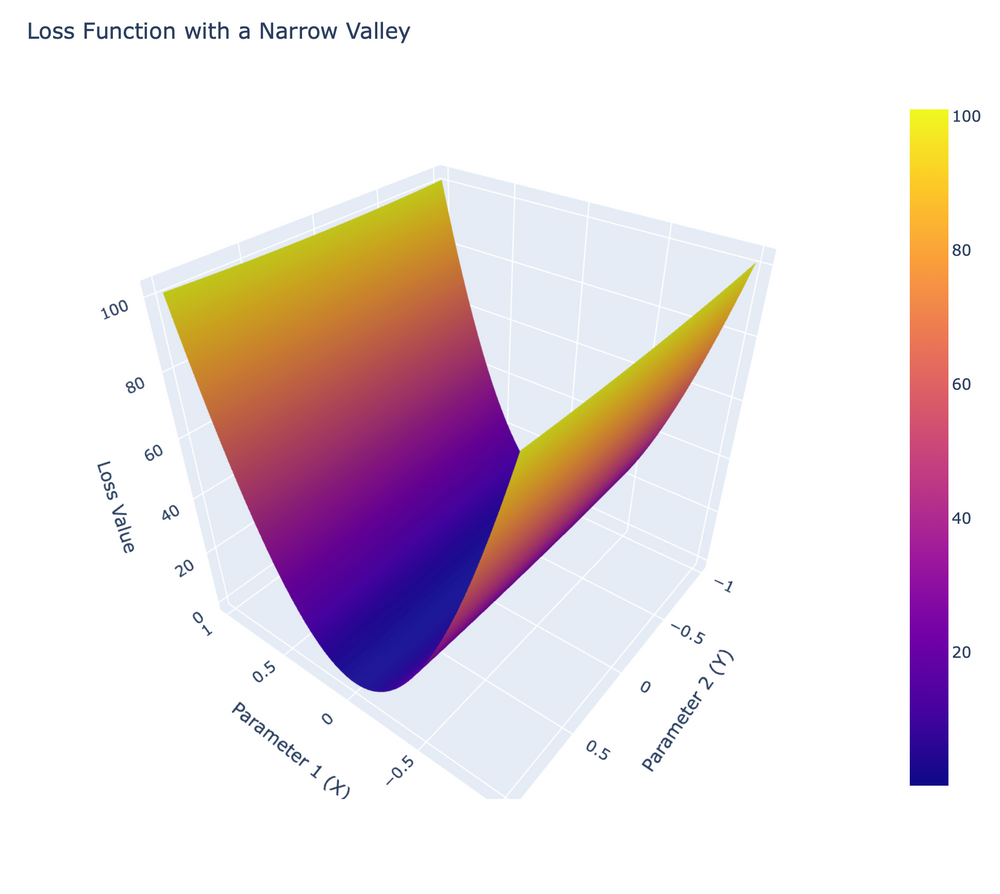

Scenario : Narrow Valley (gradient สูงในแกน X, ต่ำในแกน Y)



1. SGD (lr=0.01)

Step 1: x=-0.100, y=-0.010

Step 2: x=-0.180, y=-0.005

Step 3: x=-0.270, y=-0.013

Step 4: x=-0.340, y=-0.010

Step 5: x=-0.425, y=-0.016

ปัญหา แกว่งไปมาในแกน X, ช้าในแกน Y


2. SGD + Momentum (lr=0.01, momentum=0.9)

Step 1: x=-0.100, y=-0.010

Step 2: x=-0.270, y=-0.014

Step 3: x=-0.513, y=-0.026

Step 4: x=-0.802, y=-0.033

Step 5: x=-1.147, y=-0.046

ดีขึ้น momentum ช่วยลดการแกว่ง


3. RMSprop (lr=0.01)

Step 1: x=-0.032, y=-0.032

Step 2: x=-0.052, y=-0.017

Step 3: x=-0.071, y=-0.036

Step 4: x=-0.085, y=-0.029

Step 5: x=-0.101, y=-0.043

ดีขึ้น ปรับ LR ให้เหมาะกับแต่ละแกน


4. Adam (lr=0.01)

Step 1: x=-0.010, y=-0.010

Step 2: x=-0.020, y=-0.013

Step 3: x=-0.030, y=-0.018

Step 4: x=-0.040, y=-0.021

Step 5: x=-0.049, y=-0.026

รวมข้อดีของ Momentum + RMSprop ให้การ Convergence ที่ดีที่สุด

**หมายเหตุ** Convergence คือ กระบวนการที่ Loss Function ของ Model ลดลงเรื่อย ๆ และ Parameters ของ Model ค่อยๆ เข้าที่ หรือเข้าใกล้จุดที่ค่า Loss ต่ำที่สุด

## สรุป Adam ทำอะไรบ้าง

**Adaptive Learning Rates** ปรับ LR อัตโนมัติให้แต่ละ parameter

**Momentum** ใช้ Gradient ในอดีตช่วยตัดสินใจ เพื่อลดการแกว่งไปมา (Oscillation)

**Bias Correction** แก้ปัญหาค่าเริ่มต้นที่เป็น 0 ทำให้ช่วงแรกๆ ไม่ช้าเกินไป สำคัญมากใน 10-20 iterations แรก

# Hyperparameters ของ Adam

1. Learning Rate (α หรือ lr)
   - Default 0.001
   - Range ที่นิยม คือ 0.0001 - 0.01
   - ยิ่งน้อย = เรียนช้าแต่แม่นยำ
   - ยิ่งมาก = เรียนเร็วแต่อาจไม่ stable

2. Beta1 (β₁) - Momentum decay
   - Default 0.9
   - Range 0.8 - 0.95
   - ควบคุม Exponential decay ของ First moment
   - ยิ่งมาก = ให้น้ำหนักกับอดีตมาก

3. Beta2 (β₂) - RMSprop decay
   - Default 0.999
   - Range 0.99 - 0.9999
   - ควบคุม Exponential decay ของ Second moment
   - ยิ่งมาก = ค่า Rariance เปลี่ยนช้า

4. Epsilon (ε)
   - Default 1e-8
   - ป้องกันการหารด้วย 0
   - ไม่ค่อยต้องปรับ

## **การใช้ Adam ใน Project**

from tensorflow.keras.optimizers import Adam

# การใช้แบบ Default
model.compile(

	    optimizer='adam',  # ใช้ค่า default ทั้งหมด
        loss='categorical_crossentropy',
        metrics=['accuracy']
)

# การปรับแต่ง Hyperparameters

custom_adam = Adam(

        learning_rate=0.001, # ปรับ LR
        beta_1=0.9,          # momentum coefficient
        beta_2=0.999,        # RMSprop coefficient
        epsilon=1e-7         # numerical stability

)

model.compile(optimizer=custom_adam, ...)

# **Solution ! Adam + LR Scheduling**
Adam ปรับ Learning Rate แบบ สัมพัทธ์กับพฤติกรรมของ Gradient ของ Parameter แต่ละตัว ให้แต่ละ Parameter ส่วน Learning Rate Scheduling ปรับ Learning Rate แบบ Global ทั้งหมด

## **LAB ทดลอง Optimizer/Scheduler Combinations**

ตั้งค่าและรัน Training ด้วย SGD + Fixed LR

ตั้งค่าและรัน Training ด้วย Adam + Fixed LR

ตั้งค่าและรัน Training ด้วย Adam + Cosine Annealing

Import Library ที่ต้องใช้

In [20]:
#Import Library ที่ต้องใช้
import math, numpy as np, tensorflow as tf
import matplotlib.pyplot as plt

tf.random.set_seed(42)
np.random.seed(42)

In [22]:
#Load dataset
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.fashion_mnist.load_data()
# normalize to [0,1] และเพิ่ม channel dim สำหรับ CNN
x_train = (x_train.astype("float32") / 255.0)[..., None]
x_test  = (x_test.astype("float32")  / 255.0)[..., None]

In [23]:
#Train/Val Split (90/10)
num_train = int(len(x_train) * 0.9)
x_tr, y_tr = x_train[:num_train], y_train[:num_train]
x_val, y_val = x_train[num_train:], y_train[num_train:]

In [24]:
BATCH_SIZE = 128
EPOCHS = 12

ds_train = tf.data.Dataset.from_tensor_slices((x_tr, y_tr)).shuffle(10_000).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
ds_val   = tf.data.Dataset.from_tensor_slices((x_val, y_val)).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
ds_test  = tf.data.Dataset.from_tensor_slices((x_test, y_test)).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

steps_per_epoch = math.ceil(len(x_tr) / BATCH_SIZE)

In [25]:
#Function สร้าง Model CNN ขนาดเล็ก
def build_model():
    inputs = tf.keras.Input(shape=(28, 28, 1))
    x = tf.keras.layers.Conv2D(32, 3, padding="same", activation="relu")(inputs)
    x = tf.keras.layers.MaxPooling2D()(x)
    x = tf.keras.layers.Conv2D(64, 3, padding="same", activation="relu")(x)
    x = tf.keras.layers.MaxPooling2D()(x)
    x = tf.keras.layers.Flatten()(x)
    x = tf.keras.layers.Dense(128, activation="relu")(x)
    x = tf.keras.layers.Dropout(0.25)(x)
    outputs = tf.keras.layers.Dense(10, activation="softmax")(x)
    return tf.keras.Model(inputs, outputs)

In [26]:
#ฟังก์ชัน Train/Eval
def train_one_run(optimizer, label):
    model = build_model()
    model.compile(optimizer=optimizer,
                  loss="sparse_categorical_crossentropy",
                  metrics=["accuracy"])
    h = model.fit(ds_train,
                  validation_data=ds_val,
                  epochs=EPOCHS,
                  verbose=0)  # ลด log ให้สั้น
    test_loss, test_acc = model.evaluate(ds_test, verbose=0)
    return h.history, {"test_loss": test_loss, "test_acc": test_acc, "label": label}

In [27]:
#ตั้งค่า Optimizer/Scheduler
runs = []

# SGD + fixed LR
opt_sgd = tf.keras.optimizers.SGD(learning_rate=0.01)
hist_sgd, res_sgd = train_one_run(opt_sgd, "SGD (lr=0.01)")
runs.append(("SGD (lr=0.01)", hist_sgd, res_sgd))

In [28]:
# Adam + fixed LR
opt_adam = tf.keras.optimizers.Adam(learning_rate=0.001)
hist_adam, res_adam = train_one_run(opt_adam, "Adam (lr=0.001)")
runs.append(("Adam (lr=0.001)", hist_adam, res_adam))

In [29]:
# Adam + Cosine Annealing (CosineDecay ต่อ step)
total_steps = steps_per_epoch * EPOCHS
lr_schedule = tf.keras.optimizers.schedules.CosineDecay(
    initial_learning_rate=0.001,
    decay_steps=total_steps,
    alpha=0.0  # ปลายโค้งลดถึง 0 (ถ้าอยากไม่ถึง 0 ให้เพิ่ม alpha > 0)
)

In [30]:
opt_adam_cos = tf.keras.optimizers.Adam(learning_rate=lr_schedule)
hist_cos, res_cos = train_one_run(opt_adam_cos, "Adam + CosineDecay (base lr=0.001)")
runs.append(("Adam + CosineDecay (base lr=0.001)", hist_cos, res_cos))

In [31]:
#แสดงผลสรุป Test set
print("Test Results")
for name, h, r in runs:
    print(f"{r['label']}: test_acc={r['test_acc']:.4f}, test_loss={r['test_loss']:.4f}")

Test Results
SGD (lr=0.01): test_acc=0.8570, test_loss=0.4069
Adam (lr=0.001): test_acc=0.9201, test_loss=0.2389
Adam + CosineDecay (base lr=0.001): test_acc=0.9197, test_loss=0.2275


# **พล็อตกราฟเปรียบเทียบ**

In [32]:
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# สร้าง Subplots 1 แถว 2 คอลัมน์ สำหรับ Accuracy และ Loss
fig = make_subplots(rows=1, cols=2, subplot_titles=('Validation Accuracy vs Epoch', 'Validation Loss vs Epoch'))

# Plot Validation Accuracy
for name, h, r in runs:
    fig.add_trace(go.Scatter(y=h["val_accuracy"], mode='lines', name=name), row=1, col=1)

# Plot Validation Loss
for name, h, r in runs:
    fig.add_trace(go.Scatter(y=h["val_loss"], mode='lines', name=name, showlegend=False), row=1, col=2) # ซ่อน legend ซ้ำซ้อน

# อัปเดต Layout
fig.update_layout(
    title_text="Comparison of Optimizer Performance",
    height=500,  # ปรับความสูง
    width=1000,  # ปรับความกว้าง
    hovermode='x unified' # แสดงค่าบนเส้นเมื่อ hover
)

fig.update_xaxes(title_text="Epoch", row=1, col=1)
fig.update_yaxes(title_text="Val Accuracy", row=1, col=1)

fig.update_xaxes(title_text="Epoch", row=1, col=2)
fig.update_yaxes(title_text="Val Loss", row=1, col=2)


fig.show()

**หมายเหตุ** SGD เป็น Gradient Descent แบบธรรมดา ไม่ได้มี Momentum หรือ Adaptive learning rate ในตัว ค่า Learning Rate จึงต้อง ใหญ่พอ เพื่อให้การอัปเดตน้ำหนักขยับไปข้างหน้าได้เร็วพอ (เช่น 0.01 หรือ 0.1 ในบางงาน) ขณะที่ Adam เป็น Adaptive optimizer มีการปรับ Learning rate เองต่อพารามิเตอร์ โดยเฉลี่ยแล้วถ้าใช้ Learning Rate ใหญ่เท่า SGD จะทำให้ Loss กระโดด/ไม่เสถียร จึงนิยมใช้เล็กกว่าประมาณ 10 เท่า